# Representation Noise Comparison: `monomial_based` vs `list_based`

Compares the two genuinely distinct ways the secret monomial `Q` is represented
and leaked in this codebase:

- **`monomial_based`** - the whole-matrix hint: every one of the `n * n` entries
  of `Q` is leaked through the bitwise channel (`generate_bit_channel_hint`),
  reconstructed with **Algorithm 6** (`monomial_approximation`, the entrywise
  posterior / RowScore + Hungarian-assignment model).
- **`list_based`** - the two-vector hint: only the `n` nonzero entries are
  leaked, as a permutation list (which column) and a values list (what
  coefficient), each leaked independently (`generate_bit_channel_hint_for_list`),
  reconstructed with **Algorithm 5** (`monomial_approximation_vector`, the
  decoupled Two-Vector Model).

This notebook asks: **under the same bit-flip noise (alpha, beta), which
representation's leakage is corrupted more, and which one's own (faithful)
reconstruction algorithm recovers the true secret better** - across a range of
matrix sizes `n` and field sizes `q`?

**Why `monomial_approximation_vector` and not the folded
`compute_posterior_table_list_based` + `monomial_approximation` path** that
`planted_codeword_repair_test_search_tree.py`'s `'list_based'` branch uses:
that folded path exists purely so the two leaked lists can be fed through the
*entrywise* Algorithm 6 pipeline unchanged (needed there because the repair
stage's `build_row_domains_list_based` / search tree need the same `D_loc`
shape as the whole-matrix repair code). It is **not** the two-vector model's
own optimal reconstruction - see `monomial_approximation_vector`'s docstring
in `core/LEP_prediction_and_repair_v2.py` for why folding reintroduces a
zero-entry background term that has no counterpart in the real Two-Vector
Model. Since this notebook stops at `Q_hat` (no repair stage), there is no
reason to use the compatibility path - `monomial_approximation_vector` is the
genuinely-matching, MAP-faithful algorithm for `list_based`, exactly as
`algorithm5_demo.ipynb` already demonstrates on a single instance. This
notebook is the quantitative sweep version of that same comparison.

**This intentionally stops at `Q_hat`** - it does not run the structured
search-tree repair (Algorithms 2-4). That isolates the question this notebook
is actually asking (how much does noise corrupt each *representation*, and how
well does each one's own reconstruction algorithm undo that) from the repair
stage's very different, combinatorial cost profile - see the long-runtime
discussion around `delta=0.05` in `planted_codeword_repair_test_search_tree.py`'s
`medium_test()`. Skipping the search tree also means no generator matrix / GV
bound / planted-codeword machinery is needed at all: each instance is just a
random secret monomial, leaked once per representation, then reconstructed.

**The grid:**

- `n in {16, 32, 64, 124}` - four matrix sizes, including `medium_test()`'s
  own scale (124).
- `q in {5, 11, 31, 127}` - four field sizes, including `q=127` (LESS /
  every other sweep in this repo) and three smaller primes spanning the range.
- `(alpha, beta)` - the same 16-combo grid as
  `planted_codeword_repair_test_search_tree.py`: `alpha in {0.005, 0.01, 0.015,
  0.02}` x `beta in {0.05, 0.1, 0.15, 0.2}`, full cross product.
- 5 random seeds per `(n, q, alpha, beta)` grid point.

`4 x 4 x 16 x 5 = 1280` instances, each producing both representations'
metrics (the *same* random secret monomial is used for both representations
per instance - see `run_one_instance` below - so the comparison isolates the
representation/channel effect, not secret randomness) -> 2560 result rows.

Each instance is cheap (no generator matrix, no GV-bound search, no search
tree - just building a monomial, leaking it, and running the two posterior +
assignment steps), so the full sweep should run in well under the time
`medium_test()`'s 144-run repair sweep takes; it is still checkpointed to a
CSV (see below) so an interrupted run can simply be re-run to pick up where
it left off.

## Setup

In [17]:
import os
import sys

for _rel in ['../../core', '../core', 'core']:
    if os.path.isdir(_rel):
        sys.path.insert(0, os.path.abspath(_rel))

In [18]:
import csv
import math
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sage.all import GF, set_random_seed

from instances_generator_monomial_as_list import (
    generate_bit_channel_hint,
    generate_bit_channel_hint_for_list,
    generate_random_monomial_as_lists,
    monomial_lists_to_matrix,
)
from LEP_prediction_and_repair_v2 import (
    compute_posterior_table_exact,
    compute_vector_posteriors_list_based,
    monomial_approximation,
    monomial_approximation_vector,
    set_verbose,
)

set_verbose(False)  # flip to True for per-instance progress prints while debugging

sns.set_style("whitegrid")
PAIR_PALETTE = ['#43a2ca', '#0868ac']   # [monomial_based, list_based] - fixed categorical order
SEQ_CMAP = "GnBu"                        # magnitude (accuracy): light -> dark, one hue
DIV_CMAP = "RdBu_r"                      # polarity (accuracy difference): two hues + white midpoint

## Grid definition

In [29]:
N_VALUES = [16, 32, 64, 124, 256]
Q_VALUES = [5, 11, 31, 127]

ALPHAS = [0.005, 0.01, 0.015, 0.02]
BETAS = [0.05, 0.1, 0.15, 0.2]
ALPHA_BETA_COMBOS = [(a, b) for a in ALPHAS for b in BETAS]  # 16 combos, same grid
                                                               # as planted_codeword_repair_test_search_tree.py

SEEDS = list(range(1, 6))  # 5 seeds per (n, q, alpha, beta) grid point

REPRESENTATIONS = ['monomial_based', 'list_based']

RESULTS_CSV = os.path.join('runs', 'representation_noise_comparison.csv')
FIELDNAMES = [
    'n', 'q', 'alpha', 'beta', 'seed', 'representation',
    'row_accuracy', 'perm_accuracy', 'value_accuracy',
    'raw_matrix_entry_corruption_rate', 'raw_perm_corruption_rate', 'raw_value_corruption_rate',
    'elapsed_s',
]

total_combos = len(N_VALUES) * len(Q_VALUES) * len(ALPHA_BETA_COMBOS) * len(SEEDS)
print(f"Grid: {len(N_VALUES)} n-values x {len(Q_VALUES)} q-values x "
      f"{len(ALPHA_BETA_COMBOS)} (alpha,beta) combos x {len(SEEDS)} seeds "
      f"= {total_combos} instances -> {total_combos * len(REPRESENTATIONS)} result rows")

Grid: 5 n-values x 4 q-values x 16 (alpha,beta) combos x 5 seeds = 1600 instances -> 3200 result rows


## One instance, both representations

`run_one_instance` draws a **single** random secret monomial (as a
`(permutation, values)` pair) per `(n, q, seed)`, then leaks and reconstructs
it twice - once through each representation's own channel and reconstruction
algorithm - so the two representations are compared on the identical secret,
isolating the effect of *how it's leaked and rebuilt* from the randomness of
*what the secret happens to be*.

Metrics returned per representation:

- `row_accuracy` - fraction of the `n` rows where the reconstructed `Q_hat`
  row exactly matches the true row (same definition used throughout this
  repo's sweeps, e.g. `rows_full / n` in `planted_codeword_repair_test_search_tree.py`).
- `perm_accuracy` / `value_accuracy` (`list_based` only, `NaN` for
  `monomial_based`, which has no separate destination/value channels to
  decompose) - fraction of rows where just the destination column, or just
  the scale value, was recovered correctly (independent of each other, since
  the Two-Vector Model's value selection does not depend on the column
  assignment - see `monomial_approximation_vector`'s docstring).
- `raw_matrix_entry_corruption_rate` (`monomial_based` only) - fraction of
  the *raw leaked* `n * n` matrix entries that differ from the true entry,
  before any reconstruction - i.e. how noisy the leakage itself is.
- `raw_perm_corruption_rate` / `raw_value_corruption_rate` (`list_based`
  only) - the same idea, per leaked list, before reconstruction.

In [30]:
def run_one_instance(n, q, alpha, beta, seed):
    '''
    Builds one random secret monomial (n, q), leaks + reconstructs it through
    BOTH representations under the same (alpha, beta), and returns a list of
    two result dicts (one per representation in REPRESENTATIONS).

    :param n: degree of the monomial
    :param q: field size
    :param alpha: Pr[bit 1 -> 0] in the bitwise leakage channel
    :param beta: Pr[bit 0 -> 1] in the bitwise leakage channel
    :param seed: Sage random seed - fixes the secret monomial AND both
        representations' noise draws, for exact reproducibility
    :return: [monomial_based_row, list_based_row], each a dict matching FIELDNAMES
        (minus 'elapsed_s', added by the caller)
    '''
    set_random_seed(seed)
    F = GF(q)

    # The ONE secret monomial both representations will leak - see the
    # markdown above for why this is drawn once, not per representation.
    permutation, values = generate_random_monomial_as_lists(n, q, is_permutation=False)
    Q = monomial_lists_to_matrix(n, q, permutation, values)

    results = []

    # --- monomial_based: whole n x n matrix hint, Algorithm 6 ---
    t0 = time.time()
    Q_noisy = generate_bit_channel_hint(Q, q, alpha, beta)
    n_entries = n * n
    n_wrong_entries = sum(
        1 for i in range(n) for j in range(n)
        if int(Q_noisy[i][j]) != int(Q[i, j])
    )
    posterior_table = compute_posterior_table_exact(Q_noisy, n, q, alpha, beta, is_permutation=False)
    Q_hat, S, D_loc, pi = monomial_approximation(posterior_table, F)
    rows_full = sum(1 for i in range(n) if list(Q_hat[i]) == list(Q[i]))
    elapsed_mono = time.time() - t0

    results.append({
        'n': n, 'q': q, 'alpha': alpha, 'beta': beta, 'seed': seed,
        'representation': 'monomial_based',
        'row_accuracy': float(rows_full / n),
        'perm_accuracy': float('nan'),
        'value_accuracy': float('nan'),
        'raw_matrix_entry_corruption_rate': float(n_wrong_entries / n_entries),
        'raw_perm_corruption_rate': float('nan'),
        'raw_value_corruption_rate': float('nan'),
        'elapsed_s': elapsed_mono,
    })

    # --- list_based: two-vector hint, Algorithm 5 (monomial_approximation_vector) ---
    t0 = time.time()
    perm_bit_width = math.ceil(math.log2(n))
    value_bit_width = math.ceil(math.log2(q))
    noisy_permutation = generate_bit_channel_hint_for_list(permutation, alpha, beta, bit_width=perm_bit_width)
    noisy_values = generate_bit_channel_hint_for_list(values, alpha, beta, bit_width=value_bit_width)

    n_wrong_perm = sum(1 for i in range(n) if int(noisy_permutation[i]) != permutation[i])
    n_wrong_value = sum(1 for i in range(n) if int(noisy_values[i]) != int(values[i]))

    p_perm, p_scale = compute_vector_posteriors_list_based(
        noisy_permutation, noisy_values, n, q, alpha, beta, is_permutation=False
    )
    Q_hat_v, S_perm, d_hat, pi_hat = monomial_approximation_vector(p_perm, p_scale, F)

    n_perm_correct = sum(1 for i in range(n) if pi_hat[i] == permutation[i])
    n_value_correct = sum(1 for i in range(n) if d_hat[i] == values[i])
    n_row_correct = sum(1 for i in range(n) if pi_hat[i] == permutation[i] and d_hat[i] == values[i])
    elapsed_list = time.time() - t0

    results.append({
        'n': n, 'q': q, 'alpha': alpha, 'beta': beta, 'seed': seed,
        'representation': 'list_based',
        'row_accuracy': float(n_row_correct / n),
        'perm_accuracy': float(n_perm_correct / n),
        'value_accuracy': float(n_value_correct / n),
        'raw_matrix_entry_corruption_rate': float('nan'),
        'raw_perm_corruption_rate': float(n_wrong_perm / n),
        'raw_value_corruption_rate': float(n_wrong_value / n),
        'elapsed_s': elapsed_list,
    })

    return results

## Run the sweep (checkpointed to CSV, resumable)

Appends rows to `RESULTS_CSV` as they're computed, and skips any
`(n, q, alpha, beta, seed)` combination already present in that file - so if
this cell is interrupted, just re-run it to continue where it left off,
exactly like `planted_codeword_repair_test_search_tree.py`'s own
`completed_combos.json` checkpointing.

In [31]:
os.makedirs('runs', exist_ok=True)

def _load_completed(path):
    if not os.path.exists(path):
        return set()
    done = set()
    with open(path, newline='') as f:
        for row in csv.DictReader(f):
            done.add((int(row['n']), int(row['q']), float(row['alpha']), float(row['beta']), int(row['seed'])))
    return done

completed = _load_completed(RESULTS_CSV)
write_header = not os.path.exists(RESULTS_CSV)

combos = [
    (n, q, alpha, beta, seed)
    for n in N_VALUES
    for q in Q_VALUES
    for (alpha, beta) in ALPHA_BETA_COMBOS
    for seed in SEEDS
]
print(f"Total combinations: {len(combos)}; already completed: {len(completed)}")

with open(RESULTS_CSV, 'a', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=FIELDNAMES)
    if write_header:
        writer.writeheader()

    t_start = time.time()
    for idx, (n, q, alpha, beta, seed) in enumerate(combos, start=1):
        key = (n, q, alpha, beta, seed)
        if key in completed:
            continue

        rows = run_one_instance(n, q, alpha, beta, seed)
        for row in rows:
            writer.writerow(row)
        f.flush()

        if idx % 20 == 0 or idx == len(combos):
            elapsed = time.time() - t_start
            print(f"  [{idx}/{len(combos)}] n={n} q={q} alpha={alpha} beta={beta} seed={seed} "
                  f"({elapsed:.1f}s elapsed)")

print(f"\nSweep finished (or already complete). Results in: {RESULTS_CSV}")

Total combinations: 1600; already completed: 1280
  [1300/1600] n=256 q=5 alpha=0.00500000000000000 beta=0.200000000000000 seed=5 (45.9s elapsed)
  [1320/1600] n=256 q=5 alpha=0.0100000000000000 beta=0.200000000000000 seed=5 (92.6s elapsed)
  [1340/1600] n=256 q=5 alpha=0.0150000000000000 beta=0.200000000000000 seed=5 (141.1s elapsed)
  [1360/1600] n=256 q=5 alpha=0.0200000000000000 beta=0.200000000000000 seed=5 (196.5s elapsed)
  [1380/1600] n=256 q=11 alpha=0.00500000000000000 beta=0.200000000000000 seed=5 (258.0s elapsed)
  [1400/1600] n=256 q=11 alpha=0.0100000000000000 beta=0.200000000000000 seed=5 (317.0s elapsed)
  [1420/1600] n=256 q=11 alpha=0.0150000000000000 beta=0.200000000000000 seed=5 (376.6s elapsed)
  [1440/1600] n=256 q=11 alpha=0.0200000000000000 beta=0.200000000000000 seed=5 (436.5s elapsed)
  [1460/1600] n=256 q=31 alpha=0.00500000000000000 beta=0.200000000000000 seed=5 (533.5s elapsed)
  [1480/1600] n=256 q=31 alpha=0.0100000000000000 beta=0.200000000000000 seed=5 

## Load results

In [32]:
df = pd.read_csv(RESULTS_CSV)
# Older rows were written under the Sage preparser, which stores ratios as exact
# Rationals (e.g. '15/16'); parse those back to floats.
from fractions import Fraction
for _col in ['row_accuracy', 'perm_accuracy', 'value_accuracy',
             'raw_matrix_entry_corruption_rate', 'raw_perm_corruption_rate', 'raw_value_corruption_rate']:
    df[_col] = df[_col].map(lambda v: float(Fraction(v)) if isinstance(v, str) and v != 'nan' else float(v))
print(f"{len(df)} result rows loaded ({df['representation'].value_counts().to_dict()})")
df.head()

3200 result rows loaded ({'monomial_based': 1600, 'list_based': 1600})


,n,q,alpha,beta,seed,representation,row_accuracy,perm_accuracy,value_accuracy,raw_matrix_entry_corruption_rate,raw_perm_corruption_rate,raw_value_corruption_rate,elapsed_s
0,16,5,0.005,0.05,1,monomial_based,0.9375,NaN,NaN,0.113281,NaN,NaN,0.009297
1,16,5,0.005,0.05,1,list_based,1.0000,1.0,1.000,NaN,0.1250,0.0000,0.001670
2,16,5,0.005,0.05,2,monomial_based,0.8125,NaN,NaN,0.156250,NaN,NaN,0.006568
3,16,5,0.005,0.05,2,list_based,0.8750,1.0,0.875,NaN,0.0625,0.1875,0.001802
4,16,5,0.005,0.05,3,monomial_based,0.8125,NaN,NaN,0.136719,NaN,NaN,0.006530


## Row accuracy vs. alpha and beta

Two heatmaps (one hue, light -> dark = higher accuracy), averaged over every
`n`, `q`, and seed, plus the difference between them (diverging, white at
zero) to show directly where one representation is more fragile than the
other.

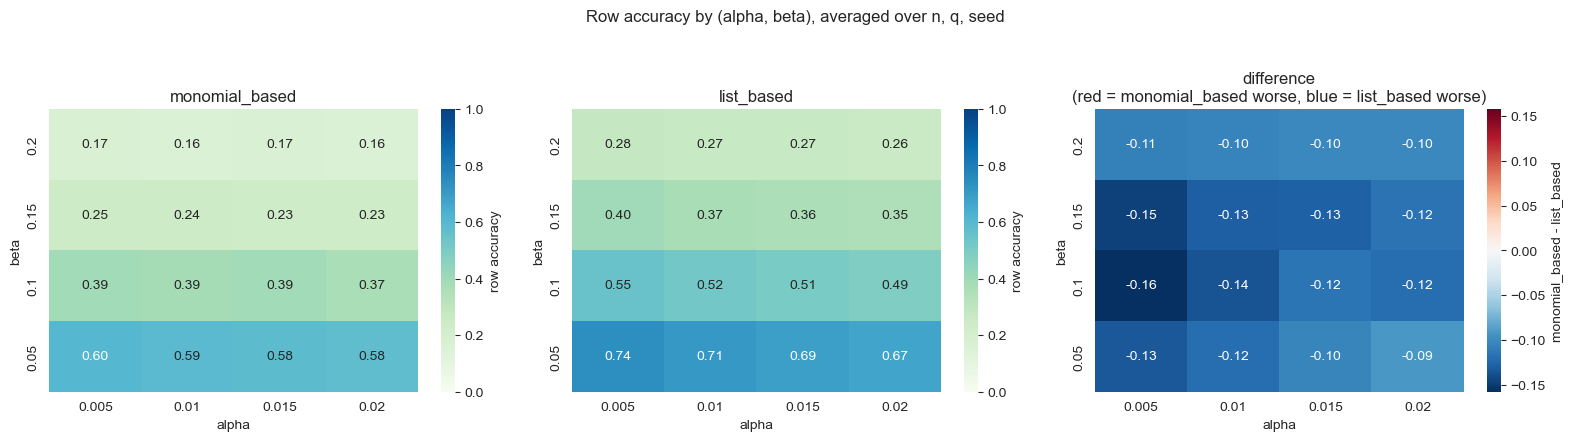

In [33]:
pivot_mono = df[df.representation == 'monomial_based'].pivot_table(
    index='beta', columns='alpha', values='row_accuracy', aggfunc='mean')
pivot_list = df[df.representation == 'list_based'].pivot_table(
    index='beta', columns='alpha', values='row_accuracy', aggfunc='mean')
pivot_diff = pivot_mono - pivot_list  # positive = monomial_based more accurate here

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

sns.heatmap(pivot_mono, ax=axes[0], cmap=SEQ_CMAP, vmin=0, vmax=1,
            annot=True, fmt=".2f", cbar_kws={'label': 'row accuracy'})
axes[0].set_title('monomial_based')
axes[0].invert_yaxis()

sns.heatmap(pivot_list, ax=axes[1], cmap=SEQ_CMAP, vmin=0, vmax=1,
            annot=True, fmt=".2f", cbar_kws={'label': 'row accuracy'})
axes[1].set_title('list_based')
axes[1].invert_yaxis()

lim = max(0.01, pivot_diff.abs().to_numpy().max())
sns.heatmap(pivot_diff, ax=axes[2], cmap=DIV_CMAP, center=0, vmin=-lim, vmax=lim,
            annot=True, fmt=".2f", cbar_kws={'label': 'monomial_based - list_based'})
axes[2].set_title('difference\n(red = monomial_based worse, blue = list_based worse)')
axes[2].invert_yaxis()

for ax in axes:
    ax.set_xlabel('alpha')
    ax.set_ylabel('beta')

fig.suptitle('Row accuracy by (alpha, beta), averaged over n, q, seed', y=1.04)
fig.tight_layout()
plt.show()

## Row accuracy vs. matrix size (n) and field size (q)

Same idea, now averaged over every `(alpha, beta)` combo and seed instead, to
see whether one representation degrades faster as the problem scales up.

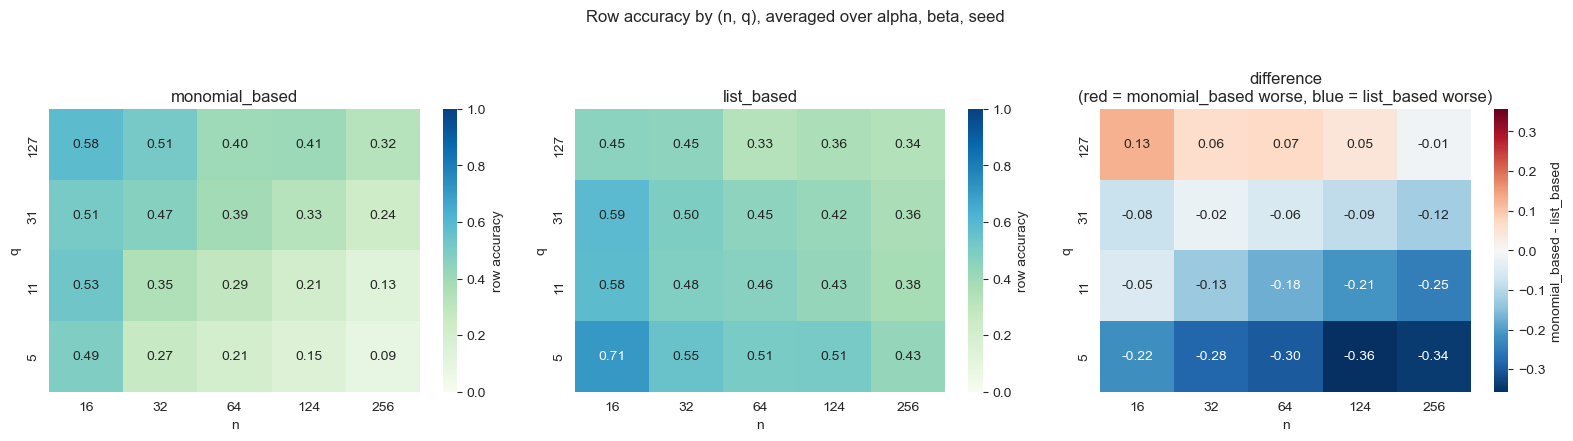

In [34]:
pivot_mono_nq = df[df.representation == 'monomial_based'].pivot_table(
    index='q', columns='n', values='row_accuracy', aggfunc='mean')
pivot_list_nq = df[df.representation == 'list_based'].pivot_table(
    index='q', columns='n', values='row_accuracy', aggfunc='mean')
pivot_diff_nq = pivot_mono_nq - pivot_list_nq

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

sns.heatmap(pivot_mono_nq, ax=axes[0], cmap=SEQ_CMAP, vmin=0, vmax=1,
            annot=True, fmt=".2f", cbar_kws={'label': 'row accuracy'})
axes[0].set_title('monomial_based')
axes[0].invert_yaxis()

sns.heatmap(pivot_list_nq, ax=axes[1], cmap=SEQ_CMAP, vmin=0, vmax=1,
            annot=True, fmt=".2f", cbar_kws={'label': 'row accuracy'})
axes[1].set_title('list_based')
axes[1].invert_yaxis()

lim_nq = max(0.01, pivot_diff_nq.abs().to_numpy().max())
sns.heatmap(pivot_diff_nq, ax=axes[2], cmap=DIV_CMAP, center=0, vmin=-lim_nq, vmax=lim_nq,
            annot=True, fmt=".2f", cbar_kws={'label': 'monomial_based - list_based'})
axes[2].set_title('difference\n(red = monomial_based worse, blue = list_based worse)')
axes[2].invert_yaxis()

for ax in axes:
    ax.set_xlabel('n')
    ax.set_ylabel('q')

fig.suptitle('Row accuracy by (n, q), averaged over alpha, beta, seed', y=1.04)
fig.tight_layout()
plt.show()

## `list_based` channel breakdown: destination vs. scale

`list_based` leaks two channels with *different bit widths* under the same
`(alpha, beta)` - the permutation list uses `ceil(log2(n))` bits per entry
(grows with `n`) while the values list always uses `ceil(log2(q))` bits
(grows with `q`). More bits means more chances for at least one flip, so the
two channels are not equally reliable even at the same alpha/beta - this
shows which one is driving `list_based`'s errors, and how that shifts as `n`
and `q` vary independently.

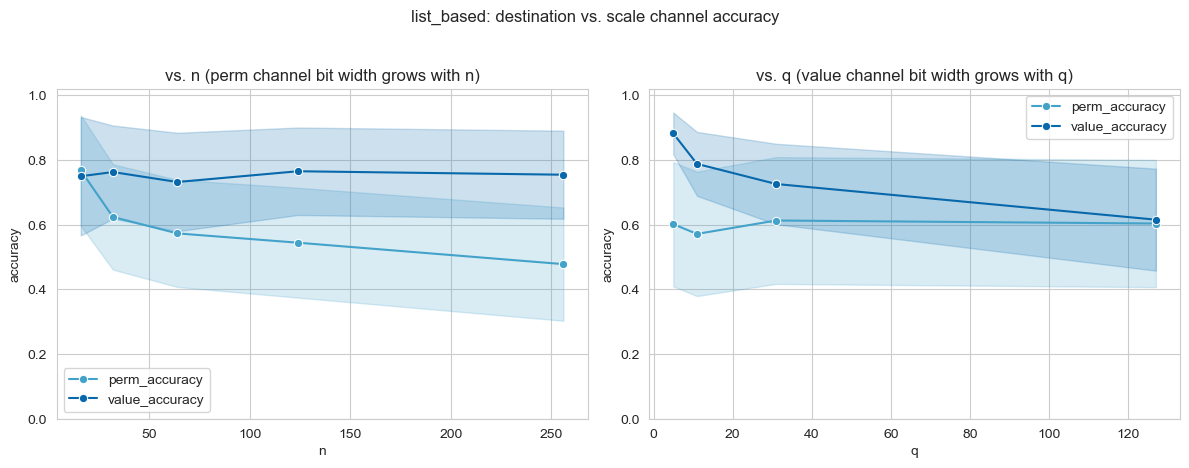

In [35]:
list_df = df[df.representation == 'list_based']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.lineplot(data=list_df, x='n', y='perm_accuracy', marker='o', color=PAIR_PALETTE[0],
             errorbar='sd', ax=axes[0], label='perm_accuracy')
sns.lineplot(data=list_df, x='n', y='value_accuracy', marker='o', color=PAIR_PALETTE[1],
             errorbar='sd', ax=axes[0], label='value_accuracy')
axes[0].set_title('vs. n (perm channel bit width grows with n)')
axes[0].set_ylabel('accuracy')
axes[0].set_ylim(0, 1.02)
axes[0].legend()

sns.lineplot(data=list_df, x='q', y='perm_accuracy', marker='o', color=PAIR_PALETTE[0],
             errorbar='sd', ax=axes[1], label='perm_accuracy')
sns.lineplot(data=list_df, x='q', y='value_accuracy', marker='o', color=PAIR_PALETTE[1],
             errorbar='sd', ax=axes[1], label='value_accuracy')
axes[1].set_title('vs. q (value channel bit width grows with q)')
axes[1].set_ylabel('accuracy')
axes[1].set_ylim(0, 1.02)
axes[1].legend()

fig.suptitle('list_based: destination vs. scale channel accuracy', y=1.03)
fig.tight_layout()
plt.show()

## How much does reconstruction buy back over raw leakage noise?

Scatter of each representation's *raw* (pre-reconstruction) corruption rate
against its *final* row accuracy after `monomial_approximation` /
`monomial_approximation_vector` - the vertical gap above the diagonal is
exactly what each reconstruction algorithm recovers from noisy leakage alone.

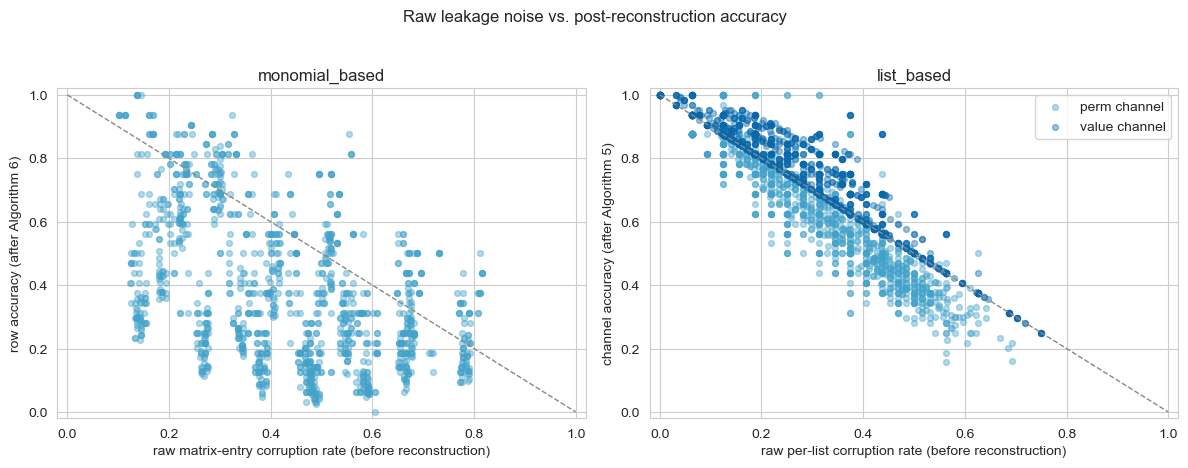

In [28]:
mono_df = df[df.representation == 'monomial_based']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(mono_df['raw_matrix_entry_corruption_rate'], mono_df['row_accuracy'],
                alpha=0.4, s=18, color=PAIR_PALETTE[0])
axes[0].plot([0, 1], [1, 0], color='#888888', linestyle='--', linewidth=1)
axes[0].set_xlabel('raw matrix-entry corruption rate (before reconstruction)')
axes[0].set_ylabel('row accuracy (after Algorithm 6)')
axes[0].set_title('monomial_based')
axes[0].set_xlim(-0.02, 1.02)
axes[0].set_ylim(-0.02, 1.02)

axes[1].scatter(list_df['raw_perm_corruption_rate'], list_df['perm_accuracy'],
                alpha=0.4, s=18, color=PAIR_PALETTE[0], label='perm channel')
axes[1].scatter(list_df['raw_value_corruption_rate'], list_df['value_accuracy'],
                alpha=0.4, s=18, color=PAIR_PALETTE[1], label='value channel')
axes[1].plot([0, 1], [1, 0], color='#888888', linestyle='--', linewidth=1)
axes[1].set_xlabel('raw per-list corruption rate (before reconstruction)')
axes[1].set_ylabel('channel accuracy (after Algorithm 5)')
axes[1].set_title('list_based')
axes[1].set_xlim(-0.02, 1.02)
axes[1].set_ylim(-0.02, 1.02)
axes[1].legend()

fig.suptitle('Raw leakage noise vs. post-reconstruction accuracy', y=1.03)
fig.tight_layout()
plt.show()

## Takeaways

Run the sweep and the plots above, then summarize here what the grid actually
shows - in particular:

- Which representation's row accuracy degrades faster as alpha/beta increase?
- Does that ranking flip anywhere in the (n, q) grid, or hold everywhere?
- For `list_based`, is the destination (permutation) channel or the scale
  (value) channel the dominant source of error, and does that depend on
  whether `n` or `q` is larger?
- How much of each representation's final error is *recoverable* (gap between
  raw corruption and post-reconstruction accuracy in the last plot) vs. just
  inherent to the leakage itself?